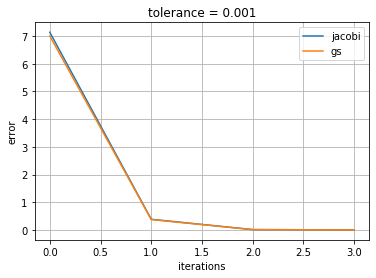

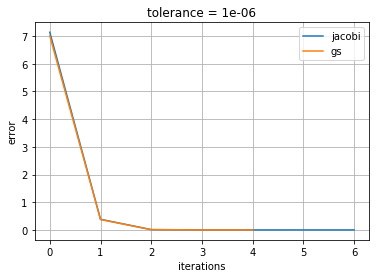

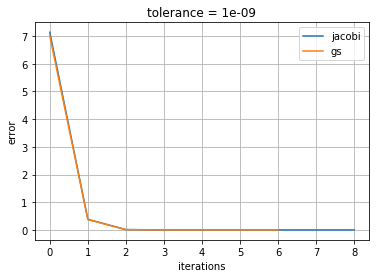

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def jacobi(A, b, x0, tol, maxIter):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(maxIter):
        xnew = np.zeros_like(x)
        
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            xnew[i] = (b[i] - s) / A[i][i]
        
        errors.append(np.linalg.norm(xnew - x, ord=np.inf))
                
        if np.linalg.norm(xnew - x, ord=np.inf) < tol:
            return xnew, k+1, errors
        
        x = xnew
        
    return x, maxIter, errors

def gs(A, b, x0, tol, maxIter):
    n = len(b)
    x = x0.copy()
    errors = []
    
    for k in range(maxIter):
        xnew = x.copy()
        
        for i in range(n):
            s1 = sum(A[i][j] * xnew[j] for j in range(i))
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            xnew[i] = (b[i] - s1 - s2) / A[i][i]
            
        errors.append(np.linalg.norm(xnew - x, ord=np.inf))
                
        if np.linalg.norm(xnew - x, ord=np.inf) < tol:
            return xnew, k+1, errors
        
        
        x = xnew
        
    return x, maxIter, errors

A = np.array([
    [3, -0.1, -0.2],
    [0.1, 7, -0.3],
    [0.3, -0.2, 10]
], dtype=float)

b = np.array([7.85, -19.3, 71.4], dtype=float)

x0 = np.zeros_like(b)
maxIter = 1000
tols = [1e-3, 1e-6, 1e-9]

for tol in tols:
    xj, iterj, errj = jacobi(A, b, x0, tol, maxIter)
    xg, iterg, errg = gs(A, b, x0, tol, maxIter)
    
    plt.figure()
    plt.plot(errj, label="jacobi")
    plt.plot(errg, label="gs")
    plt.xlabel("iterations")
    plt.ylabel("error")
    plt.title(f"tolerance = {tol}")
    plt.legend()
    plt.grid()
    plt.show()
    
## Discussion: A lower tolerance will require more iterations for both funciotns because 
##             it is more precise, meaning it will require more tries to be more exact. 
##             However, a tolerancedecrease of 1e-3 does not mean that the iterations
##             increase by 1000.